# Pytorch computer vision

## 0. Computer vision libraries in pytorch

* ['torchvision']
* torchvision.dataset - get datasets and data loading functions for computer vision
* torchvision.models - get pretrained computer vision models that you can leverage for your own computer
* torchvision.transforms - functions for manipulating your vision data (images) to be suitable for use with an Ml model
* torch.utils.data.Dataset - Base dataset class for pytorch
* torch.utils.daat.Dataloader- Creates a python iterable over a dataset

In [ ]:
# import pytorch
import torch
from torch import nn
#import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# import matplotlib for visualization
import matplotlib.pyplot as plt

# check version
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


## Getting dataset

The daat set we will be FashionMNISt from torchvision.datasets

In [ ]:
# set up training data
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root ="data", # where the download data to
    train = True,# do we want the training daatset?
    download = True, # do we want to download the dataset
    transform = torchvision.transforms.ToTensor(), # how we do want to transform the data ?
    target_transform = None # how do we want to transform the lables/target?

)
test_data =  datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

In [ ]:
len(train_data),len(test_data)

(60000, 10000)

In [ ]:
# First training example
image,label = train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx


{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
# check the shape of our image
print(f"image shape:{image.shape}->[color_channels,height,width]")
print(f"image label:{class_names[label]}")

image shape:torch.Size([1, 28, 28])->[color_channels,height,width]
image label:Ankle boot


## 1.2 Visualiz our data

image shape:torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

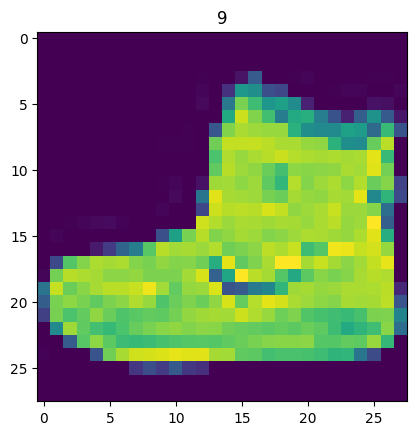

In [ ]:
import matplotlib.pyplot as plt
image,label = train_data[0]
print(f"image shape:{image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

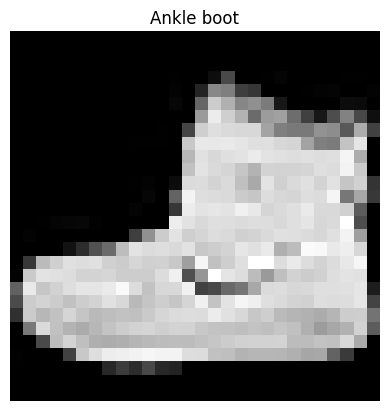

In [ ]:
plt.imshow(image.squeeze(),cmap= "gray")
plt.title(class_names[label])
plt.axis(False)

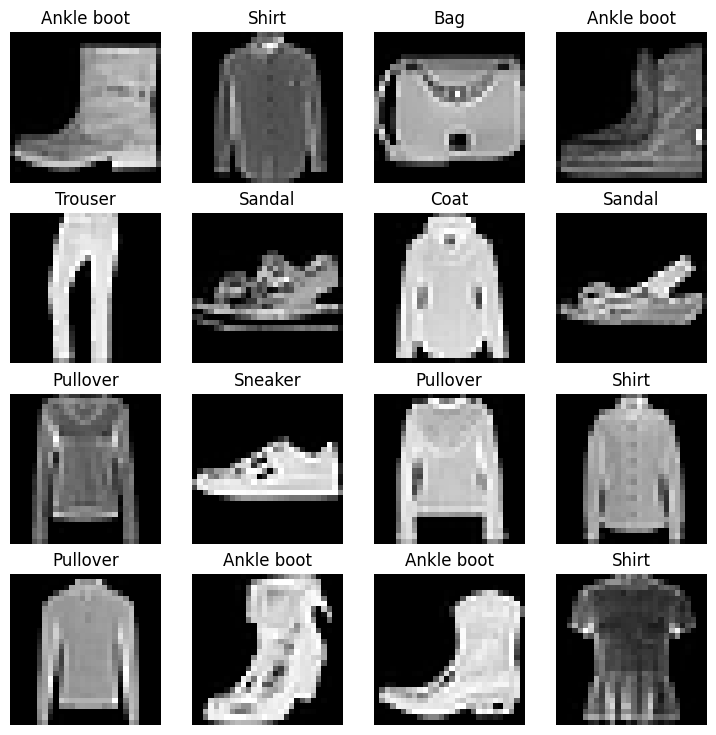

In [ ]:
#plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows , cols = 4,4
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),size= [1]).item()
  img,label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap= "gray")
  plt.title(class_names[label])
  plt.axis(False)



DO you think these items of clothing could be modelled with pure linear line? or non linearities?

In [ ]:
train_data,test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. prepare dataloader
right now , our data is in pytorch Datasets.
dataloader turns data into python iterable
more specifically we want to turn daat into batches(or mini batches)

why we would do this?
1. it is more computationally efficient, as in your computer hardware may not be able to look (store in memor) at 60000 images in one hit.So we break it doen to 32 images at a time (batch size of 32)

2. It gives our neural network more chances to update its gradient per epoch.

In [ ]:
from torch.utils.data import DataLoader
# Setup batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = False)
test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7cfe47367820>,
 <torch.utils.data.dataloader.DataLoader at 0x7cfe471cae70>)

In [ ]:
#   Lets check out what we have created
print(f"DataLoaders:{train_dataloader,test_dataloader}")
print(f"length of train_dataloader:{len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"length of test_dataloader :{len(test_dataloader)} batches of {BATCH_SIZE}")

DataLoaders:(<torch.utils.data.dataloader.DataLoader object at 0x7cfe47367820>, <torch.utils.data.dataloader.DataLoader object at 0x7cfe471cae70>)
length of train_dataloader:1875 batches of 32
length of test_dataloader :313 batches of 32


In [ ]:
# check whats inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

image size: torch.Size([1, 28, 28])
label:8 , label size :torch.Size([])


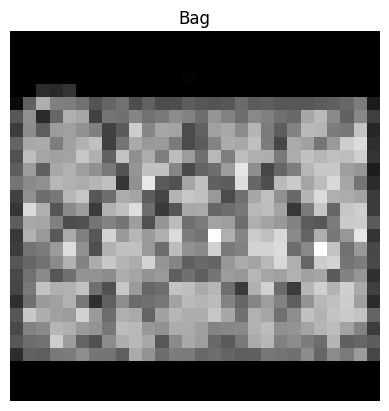

In [ ]:
# show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch),size=[1]).item()
img,label = train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"image size: {img.shape}")
print(f"label:{label} , label size :{label.shape}")

## 3. Model 0: Build a basline model
When starting to build a series of machine learning modelling ecperiments , its best practice to start with a basline model
A basline model is a simple model you will try and improve upon with subsequent models/experiments

In other words : start simply and add complexiry when necessary

In [ ]:
# create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # perform foward pass
# Print out what happened
print(f"Shape before flattening :{x.shape}")
print(f"shape before falttening :{output.shape}") # [color channels,height*weight]


Shape before flattening :torch.Size([1, 28, 28])
shape before falttening :torch.Size([1, 784])


In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape :int):
    super().__init__()
    self.layer_stack =  nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape,out_features=hidden_units ),
        nn.Linear(in_features = hidden_units,out_features = output_shape)
    )

  def forward(self,x):
      return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)

#setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape = 784, # this is 28*28,
    hidden_units = 10, # how many units in hidden layer
    output_shape = len(class_names) # one for ebery class
).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss function ,oprimizer and evolution matrics

* Loss function - since we are working with multi-class data , our loss functionn will be nn.CrossEntropyLoss()

* Optimizer - our optimizer torch.optim.SGD() (stochastic gradient descent)

* Evaluation metric - since we are working on classification problem lets use accuracy as our evaluation metric

In [ ]:
import requests
from pathlib import Path
# Download helper functions from learn pytorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

helper_functions.py already exists


In [ ]:
# import accuracy metric
from helper_functions import accuracy_fn

#setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.1)

## 3. creating a function to time out exepriments
Machine learning is eperimental

 Two of the main things you will often want to track are:
 1. Model's performance(loss and accuracy values)
 2. How fast it runs

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device : torch.device = None):
  """ print difference btween start and end time."""
  total_time = end-start
  print(f"Train time on {device} : {total_time:.3f} seconds")
  return total_time

In [ ]:
start_time= timer()
# some code
end_time = timer()
print_train_time(start = start_time, end = end_time, device = "cpu")


Train time on cpu : 0.000 seconds


0.00016065499949036166

## 3.3 Creating a training loop and training a model on batches of data
1. Loop through epochs.
2. Loop through training batches , perform training steps, calculate the train loss *per batch*
3. Loop through tetsing batches, perform testing steps , calculate the test loss per batch
4. print out what happenings
5. timer

In [ ]:
# import tqdm for progress bar
from tqdm.auto import tqdm

# set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# St the number of epochs
epochs = 3

# create training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch :{epoch}\n-----")

  #  Training loss
  train_loss = 0

# Add a loop through the training batches
  for batch,(X,y) in enumerate(train_dataloader):
    model_0.train()

    # 1. forward pass
    y_pred = model_0(X)

    # 2. Calculate loss (per batch)
    loss = loss_fn(y_pred,y)
    train_loss +=loss # accumulate train loss

    # 3. optumizer zero grad
    optimizer.zero_grad()

    # 4. backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # print out whats happening
    if batch % 400 ==0:
      print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} sample")
  #Divide total train loss by lenth of train dataloader
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss,test_acc = 0,0
  model_0.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      # forward pass
      test_pred = model_0(X_test)

      # 2. calculate loss(accumulatively)
      test_loss +=loss_fn(test_pred,y_test)

      #3. calculate accuracy
      test_acc += accuracy_fn(y_true = y_test,y_pred = test_pred.argmax(dim=1))
    # calculate the test loss average per batch
    test_loss /= len(test_dataloader)

    # calculate the test accuracy average per batch
    test_acc /= len(test_dataloader)
  # print our whats happening
  print(f"\n Train loss :{train_loss:.4f}| Test loss:{test_loss:.4f}| test acc:{test_acc:.4f}")

# calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0= print_train_time(start = train_time_start_on_cpu ,
                                           end = train_time_end_on_cpu,
                                           device = str(next(model_0.parameters()).device)
                                           )





  0%|          | 0/3 [00:00<?, ?it/s]

Epoch :0
-----
Looked at 0/60000 sample
Looked at 12800/60000 sample
Looked at 25600/60000 sample
Looked at 38400/60000 sample
Looked at 51200/60000 sample

 Train loss :0.5886| Test loss:0.5544| test acc:80.2716
Epoch :1
-----
Looked at 0/60000 sample
Looked at 12800/60000 sample
Looked at 25600/60000 sample
Looked at 38400/60000 sample
Looked at 51200/60000 sample

 Train loss :0.4743| Test loss:0.5186| test acc:81.9888
Epoch :2
-----
Looked at 0/60000 sample
Looked at 12800/60000 sample
Looked at 25600/60000 sample
Looked at 38400/60000 sample
Looked at 51200/60000 sample

 Train loss :0.4530| Test loss:0.5032| test acc:82.4780
Train time on cpu : 44.946 seconds


## 4 Make prediction and get Model 0 result

In [ ]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):

    loss, acc = 0, 0

    model.eval()

    with torch.inference_mode():

        for X, y in data_loader:

            # Make predictions
            y_pred = model(X)

            # Accumulate loss
            loss += loss_fn(y_pred, y)

            # Accumulate accuracy
            acc += accuracy_fn(
                y_true=y,
                y_pred=y_pred.argmax(dim=1)
            )

        # Average loss and accuracy
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss.item(),
        "model_acc": acc
    }


# Calculate model 0 results on test dataset
model_0_results = eval_model(
    model=model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5031648278236389,
 'model_acc': 82.47803514376997}

## setup device agnostic code


In [ ]:
!nvisa-smi

/bin/bash: line 1: nvisa-smi: command not found


In [ ]:
torch.cuda.is_available()

False

In [ ]:
# setup device agnostic code
import torch
device = "cpu"

## 6. model1 :Building a better model with non-linearity

  we learned about non-linearity

In [ ]:
# create a model with non linear and linear layer
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape :int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape,out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units,out_features = output_shape),
        nn.ReLU()
    )
  def forward(self,x:torch.Tensor):
    return self.layer_stack(x)

In [ ]:
model_1 = FashionMNISTModelV1(
    input_shape=784,
    hidden_units=10,
    output_shape=10
).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.1
)

### 6.1 Setup loss, optimizer and evaluation metrics

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.1)

### 6.2 Functionizing training and evaluation/testing loops

Lets create a function for:
* training loop - train_step()
* testing loop - test_step()

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

    train_loss, train_acc = 0, 0

    model.train()

    for X, y in data_loader:

        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)

        # Calculate loss
        loss = loss_fn(y_pred, y)

        train_loss += loss.item()

        # Calculate accuracy
        train_acc += accuracy_fn(
            y_true=y,
            y_pred=y_pred.argmax(dim=1)
        )

        # Zero gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Optimizer step
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.5f}")

    return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):

    test_loss, test_acc = 0, 0

    model.eval()

    with torch.inference_mode():

        for X, y in data_loader:

            X, y = X.to(device), y.to(device)

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y).item()

            test_acc += accuracy_fn(
                y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.5f}")

    return test_loss, test_acc

In [ ]:
epochs = 3

for epoch in tqdm(range(epochs), desc="Epochs"):

    print(f"\nEpoch: {epoch}\n-----")

    train_step(
        model=model_1,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )

    test_step(
        model=model_1,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

Epochs:   0%|          | 0/3 [00:00<?, ?it/s]


Epoch: 0
-----
Train loss: 1.08536 | Train acc: 65.72167
Test loss: 0.94037 | Test acc: 69.56869

Epoch: 1
-----
Train loss: 0.87376 | Train acc: 71.65667
Test loss: 0.89398 | Test acc: 70.77676

Epoch: 2
-----
Train loss: 0.84769 | Train acc: 72.27000
Test loss: 0.88217 | Test acc: 71.15615


In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5031648278236389,
 'model_acc': 82.47803514376997}

In [ ]:
# Get model_1 results dictionary
model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.8821688294410706,
 'model_acc': 71.15615015974441}

### model 2: Building convolutional neural Network
CNN's are also known ConvNets
CNN,s are known for thier capabilities to find patterns in visual data

In [ ]:
class FashionMNISTModelV2(nn.Module):
    # Model architecture that replicates TinyVGG
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units * 7 * 7,
                out_features=output_shape
            )
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        # print(f"Output shape of conv_block_1 {x.shape}")
        x = self.conv_block_2(x)
        # print(f"Output shape of conv_block_2 {x.shape}")
        x = self.classifier(x)
        # print(f"Output shape of classifier {x.shape}")
        return x

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
torch.manual_seed(42)
model_2= FashionMNISTModelV2(input_shape =1,
                             hidden_units = 10,
                             output_shape = len(class_names)).to(device)


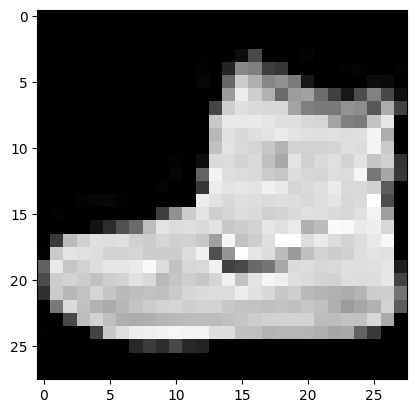

In [ ]:
plt.imshow(image.squeeze(),cmap= "gray")

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
rand_image_tensor = torch.randn(size=(1,28,28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
# pass image through model
model_2(rand_image_tensor.unsqueeze(0))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], grad_fn=<AddmmBackward0>)

In [ ]:
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

### 7.1 stepping through nn.ConV2d

In [ ]:
torch.manual_seed(42)

# create a batch of images
images = torch.randn(size = (32,3,64,64))
test_image = images[0]

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
torch.manual_seed(42)
# create single conv2d layer
conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels = 10,
                       kernel_size= (3,3),
                       stride = 1,
                       padding =0)
# pass the data through the convolution layer
conv_output = conv_layer(test_image)
# conv_output

In [ ]:
conv_output.shape

torch.Size([10, 62, 62])

## 7.2 steeping through nn.MaxPool2d

In [ ]:
# print
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
# print out original imag shape without unsqueezed dimension
print(f"Test image original shape{test_image.shape}")
print(f"test image with unsqueezed :{test_image.shape}")

# create a sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size = 2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer ():{test_image_through_conv.shape}")

# pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")



Test image original shapetorch.Size([3, 64, 64])
test image with unsqueezed :torch.Size([3, 64, 64])
Shape after going through conv_layer ():torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


In [ ]:
torch.manual_seed(42)
# create a random tensor with a similar number of dimensions to our images
random_tensor = torch.randn(size = (1,1,2,2))
print(f"random tensor :{random_tensor}")
print(f"random tensor shape:{random_tensor.shape}")

#create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"Max pool tensor :{max_pool_tensor}")
print(f"max pool tensor shape : {max_pool_tensor.shape}")

random tensor :tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
random tensor shape:torch.Size([1, 1, 2, 2])
Max pool tensor :tensor([[[[0.3367]]]])
max pool tensor shape : torch.Size([1, 1, 1, 1])


### 7.3 Setup a loss fucntion and optimizer for model_2

In [ ]:
# setup optimizer and loss_fn
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                            lr = 0.1)

### 7.4 Training and test model_2 using out training and test function

In [ ]:
torch.manual_seed(42)
#measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch:{epoch}\n----")
  train_step(model = model_2,
             data_loader = train_dataloader,
             optimizer = optimizer,
             loss_fn = loss_fn,
             accuracy_fn = accuracy_fn,
             device = device)
  test_step(model = model_2,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            accuracy_fn = accuracy_fn,
            device = device)
train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start = train_time_start_model_2,
                                            end = train_time_end_model_2,
                                            device = device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
----
Train loss: 0.60711 | Train acc: 77.73167
Test loss: 0.40983 | Test acc: 85.09385
Epoch:1
----
Train loss: 0.35902 | Train acc: 87.11667
Test loss: 0.36150 | Test acc: 87.08067
Epoch:2
----
Train loss: 0.32300 | Train acc: 88.37833
Test loss: 0.32059 | Test acc: 88.37859
Train time on cpu : 189.401 seconds


In [ ]:
# get model_2 result
model_2_results = eval_model(
    model = model_2,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn
)

In [ ]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32059377431869507,
 'model_acc': 88.37859424920129}

In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5031648278236389,
 'model_acc': 82.47803514376997}

In [ ]:
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.8821688294410706,
 'model_acc': 71.15615015974441}

## 8. compare model results and training time

In [ ]:
import pandas as pd
compare_results = pd.DataFrame(data = [model_0_results,
                                       model_1_results,model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.503165,82.478035
1,FashionMNISTModelV1,0.882169,71.156150
2,FashionMNISTModelV2,0.320594,88.378594


Text(0, 0.5, 'model')

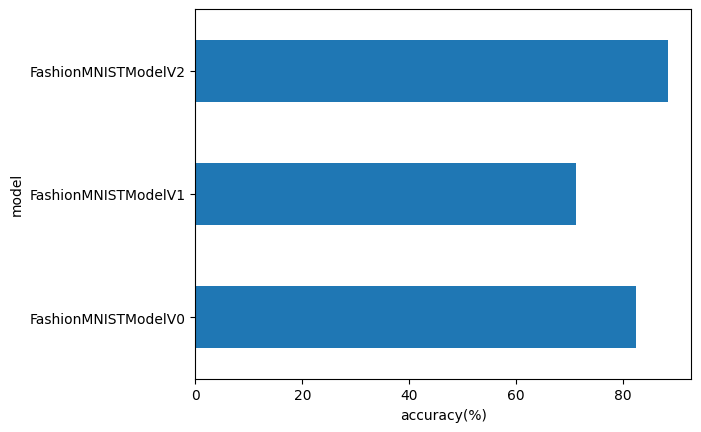

In [ ]:
# visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind = "barh")
plt.xlabel("accuracy(%)")
plt.ylabel("model")

### Make and evaluate random prediction with best model

In [ ]:
def make_predictions(model:torch.nn.Module,
                     data: list,
                     device : torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for sample in data:
      # prepare the sample(add batch dimension and padd to traget devive)
      sample = torch.unsqueeze(sample,dim = 0).to(device)

      # forward pass(model ourpur raws logits)
      pred_logit = model(sample)

      # Get prediction probability
      pred_prob = torch.softmax(pred_logit.squeeze(),dim = 0)

      # get pred_prob off the GPU for further calculation
      pred_probs.append(pred_prob.cpu())
  # stack the pred_probs to turn list into tensor
  return torch.stack(pred_probs)



In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 7.8 MB/s eta 0:00:00


In [ ]:
print(torchmetrics.__version__)

1.9.0


In [ ]:
# see if required torch matirx
import torchmetrics

In [ ]:
import mlxtend

In [ ]:
print(mlxtend.__version__)

0.23.4


In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# set up confustion and compare prediction to targets
confmat = ConfusionMatrix(num_classes = len(class_names))
confrmat_tensor =

In [ ]:
from pathlib import Path

# Create directory
MODEL_PATH = Path("models")

MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save model
MODEL_NAME = "03_model.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/03_model.pth


In [ ]:
# 1. Create a new model instance
loaded_model = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=10
)

loaded_model.load_state_dict(
    torch.load(MODEL_SAVE_PATH)
)

loaded_model.eval()

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)